In [7]:
# %cd /home/maia-user/NeuroCBIR/
%cd /mnt/alvis2/user/NeuroCBIR

/mnt/alvis2/user/NeuroCBIR


**FIGURE: EXAMPLE OF RESULT - GT FOR WHOLE BRAIN**

In [12]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
seed = 2541

### Input data
# Path to dataset
DATA_PATH = "/mnt/kth_cbh/fenda/Datasets/" #"/mnt/kth_cbh/fenda/Datasets" # "/home/maia-user/cifs/Datasets/"


In [11]:
from dev.cbir.evaluation import retrieve_topk_for_queries
import pandas as pd
import os 
DATA_PATH = "/mnt/kth_cbh/fenda/Datasets" # "/home/maia-user/cifs/Datasets/"

def load_metadata_whole_brain():
    # Constants
    
    embedding_file = "dev/data_private/results/whole_brain/eval__d_32__m_02__lid_02__mid_02__pn_005/projected_embeddings.parquet"
    metadata_path = "/mnt/alvis2/mimer_user/felixnie/batched_datasets/combined_metadata.csv"
    
    # Load and filter metadata
    clinical_ds = pd.read_csv(metadata_path)

    # Load real features from parquet
    df_embs = pd.read_parquet(embedding_file)

    # Ensure GUID is string and joinable
    df_embs["GUID"] = df_embs["GUID"].astype(str)
    clinical_ds["GUID"] = clinical_ds["GUID"].astype(str)

    # Merge on GUID
    metadata = pd.merge(clinical_ds, df_embs, on="GUID", how="inner")
    
    # Apply filters to metadata
    metadata = metadata.query("repet == 1").reset_index(drop=True)
    metadata = metadata.query("useable == 1").reset_index(drop=True)
    metadata = metadata.query("mislabel == 0").reset_index(drop=True)
    metadata['subject'] = metadata['subject'].replace('', pd.NA)
    metadata = metadata.dropna(subset=['subject']).reset_index(drop=True)
    metadata = metadata.dropna(subset=['partition']).reset_index(drop=True)

    # Convert embedding columns into a single 'features' column of vectors
    embedding_cols = [col for col in df_embs.columns if col != "GUID"]
    metadata["features"] = metadata[embedding_cols].apply(lambda row: row.to_numpy(), axis=1)
    return metadata

dataset = metadata = load_metadata_whole_brain()


In [12]:
dataset.head()

,GUID,project,subject,timepoint,repet,scan_type,field_strength,manufacturer,model_name,disease,...,23,24,25,26,27,28,29,30,31,features
0,11c21c8b-e574-466a-9459-656e09277e24,adni,002_S_0295,m00,1,T1,1.5,NaN,NaN,CN,...,0.067916,0.152295,-0.371252,-0.094262,0.089181,-0.271907,0.409790,-0.084067,-0.093518,"[-0.495286, -0.38398993, 0.12390958, -0.209169..."
1,4c6770b6-fe89-4f78-91ee-f0ede611bd90,adni,002_S_0295,m06,1,T1,1.5,GE MEDICAL SYSTEMS,SIGNA EXCITE,CN,...,0.054889,0.145912,-0.449122,-0.120189,0.028870,-0.293824,0.453405,-0.242614,-0.034025,"[-0.4796169, -0.38445374, 0.1067695, -0.212748..."
2,9dacc1e4-f52f-4b9e-9189-0db3c16b84a4,adni,002_S_0295,m12,1,T1,1.5,GE MEDICAL SYSTEMS,SIGNA EXCITE,CN,...,0.058474,0.131222,-0.393441,-0.117348,0.054179,-0.226910,0.459101,-0.188928,-0.075173,"[-0.45299572, -0.38244516, 0.13052726, -0.2447..."
3,283ba3d9-0278-4a64-98a8-5f5d2be8cd24,adni,002_S_0295,m24,1,T1,1.5,GE MEDICAL SYSTEMS,SIGNA EXCITE,CN,...,0.061563,0.140125,-0.370955,-0.065962,0.079870,-0.250665,0.464634,-0.185005,-0.023194,"[-0.46676067, -0.39243412, 0.10267915, -0.1871..."
4,ae9cdbab-6e48-4cf2-9062-91560cdfa7e4,adni,002_S_0295,m36,1,T1,1.5,GE MEDICAL SYSTEMS,SIGNA EXCITE,CN,...,0.062216,0.112751,-0.404213,-0.102154,0.087360,-0.274738,0.440113,-0.165595,-0.071786,"[-0.46838415, -0.38361886, 0.118164375, -0.235..."


In [13]:

manual_query_guids = ['I473565', 'OAS30003_MR_d0558', 'slim_25810_1']
# queries = dataset.sample(n=3, random_state=145)
queries = dataset[dataset["GUID"].isin(manual_query_guids)]
queries = queries.reset_index(drop=True)
retrieval_df = retrieve_topk_for_queries(dataset, queries, top_k=-1, exclude_same_subject=False)
retrieval_df = pd.merge(retrieval_df, metadata, left_on="query", right_on="GUID", how="left")
retrieval_df[["query"]].values.flatten().tolist()

Retrieving: 100%|██████████| 3/3 [00:00<00:00, 223.25it/s]


['OAS30003_MR_d0558', 'I473565', 'slim_25810_1']

In [94]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rcParams.update({'font.size': 7})

def crop_mri(image, target_shape=(160, 176, 208)):
    start = [48, 38, 10]
    end = np.minimum(np.array(start) + np.array(target_shape), image.shape)
    cropped = image[start[0]:end[0], start[1]:end[1], start[2]:end[2]]
    return cropped

def load_nifti(path, data_path):
    """Load a nii.gz or mgz file given a relative path from metadata."""
    full_path = os.path.join(data_path, path)
    img = nib.load(full_path)
    return crop_mri(img.get_fdata())

def plot_brain_slices(brains, titles, slice_index=None, axes=None, top_pad=7, section='axial', vertical_flip=False):
    """Plot middle slice (or given slice) of each brain in a row with top padding."""
    
    for i, (brain, title) in enumerate(zip(brains, titles)):
        # pick middle slice if not given
        if section == 'axial':
            idx = slice_index if slice_index is not None else brain.shape[1] // 2
            slice_img = brain[:, idx, : ].T
            
        elif section == 'sagittal':
            idx = slice_index if slice_index is not None else brain.shape[0] // 2
            slice_img = brain[idx, :, :].T
        elif section == 'coronal':
            idx = slice_index if slice_index is not None else brain.shape[2] // 2
            slice_img = brain[:, :, idx].T
            slice_img = slice_img[0:145]
        elif section == "custom":
            idx = slice_index if slice_index is not None else brain.shape[1] // 2
            axial = brain[:, idx, : ].T
            axial = axial[:-16]
            
            idx = slice_index if slice_index is not None else brain.shape[2] // 2
            coronal = brain[:, :, idx].T
            coronal = coronal[0:145]
            coronal = np.flipud(coronal)

            slice_img = np.concatenate([axial, coronal], axis=0)

        # add top padding (rows of zeros)
        slice_img_padded = np.pad(slice_img, ((0, top_pad), (0, 0)), mode='constant', constant_values=0)

        if vertical_flip:
            slice_img_padded = np.flipud(slice_img_padded)

        axes[i].imshow(slice_img_padded, cmap="gray", origin="lower")
        axes[i].axis("off")

        axes[i].text(
            0.015, 0.97, 
            title,
            horizontalalignment='left', 
            verticalalignment='top', 
            transform=axes[i].transAxes,
            color='w', fontsize=5, fontweight="bold"
        )


In [ ]:

# Example usage:
query_guid = "I473565"  # pick one from your metadata
row = retrieval_df.loc[retrieval_df["query"] == query_guid].iloc[0]
query_subject = row["subject"]  # store once outside loop

# Load query + top1–5
paths = [row["brain"]]
titles = ["(A)"]

# Plot top K
caps = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
K = 12
title_caps = [f"{caps[i+1]}" for i in range(K)]
title_tops = [f"top{i+1}" for i in range(K)]


# figure
cm = 1/2.54 
fig, axes = plt.subplots(1, K+1, figsize=(18.35*cm, 5*cm))

for i, col in enumerate(title_tops):
    guid = row[col]
    match_row = metadata.loc[metadata["GUID"] == guid].iloc[0]
    paths.append(match_row["brain"])
    titles.append(f"{title_caps[i]} {"✔" if match_row["subject"] == query_subject else "✘"}")

# Load brain volumes
brains = [load_nifti(p, DATA_PATH) for p in paths]

# Plot mid-slices
plot_brain_slices(brains, titles, axes=axes)

# Caption
n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
print(f"(A) Query: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
print("Other scans:")
for t_cap, col in zip(title_caps, title_tops):
    guid = row[col]
    project = metadata.loc[metadata["GUID"] == guid]["project"].iloc[0]
    print(f"{t_cap} {guid} - {project}")
    

plt.tight_layout()
plt.show()




In [15]:
all_brains = []

(A.1): OAS30003_MR_d0558 from subject OAS30003 with a total of 7.
Other scans:
(A.2) OAS30003_MR_d2669 - oasis3
(A.3) OAS30003_MR_d1631 - oasis3
(A.4) OAS30003_MR_d3320 - oasis3
(A.5) OAS30003_MR_d2682 - oasis3
(A.6) OAS30003_MR_d3731 - oasis3
(A.7) OAS30801_MR_d0097 - oasis3
(A.8) 11564512-0264-4b79-9254-c407cac05bf9 - adni
(A.9) 408af3ef-0124-4374-9f24-23cbce1d3344 - adni
(A.10) 3520bb48-bfbb-40ed-9666-5df05b78f789 - adni
(A.11) OAS30906_MR_d0035 - oasis3
(A.12) OAS30003_MR_d4954 - oasis3
(B.1): I473565 from subject 4 with a total of 3.
Other scans:
(B.2) I164080 - aibl
(B.3) I153522 - aibl
(B.4) I136619 - aibl
(B.5) miriad_246_7_MR_1 - miriad
(B.6) I246678 - aibl
(B.7) I138782 - aibl
(B.8) I445686 - aibl
(B.9) miriad_246_6_MR_1 - miriad
(B.10) miriad_246_4_MR_1 - miriad
(B.11) miriad_246_2_MR_1 - miriad
(B.12) miriad_246_3_MR_1 - miriad
(C.1): slim_25810_1 from subject 25810 with a total of 3.
Other scans:
(C.2) slim_25810_2 - slim
(C.3) slim_30919_1 - slim
(C.4) slim_30999_1 - slim

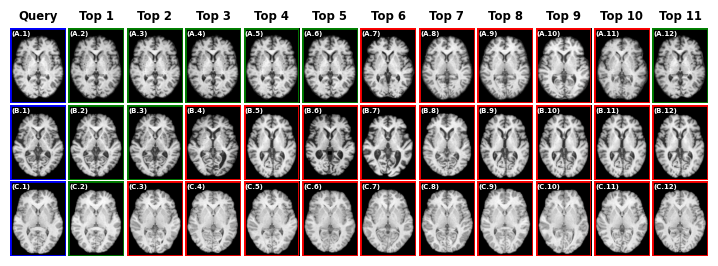

In [26]:
import matplotlib.patches as patches

K = 11

caps = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

queries_guid = retrieval_df[["query"]].values.flatten().tolist()
title_capss = [[f"({caps[i]}.{j})" for j in range(1, K+2)] for i in range(len(queries_guid))]
column_names = [f"top{i+1}" for i in range(K)]
title_tops = ["Query"] + [f"Top {i+1}" for i in range(K)]

# figure
cm = 1/2.54 
n_queries = len(queries_guid)
fig, axess = plt.subplots(n_queries, K+1, figsize=(18.35*cm, 6.7*cm))#, figsize=(18*cm, n_queries*4.1*cm))

for i_q, (axes, query_guid, title_caps) in enumerate(zip(axess, queries_guid, title_capss)):
# axes = axess[0]

    # Example usage:
    row = retrieval_df.loc[retrieval_df["query"] == query_guid].iloc[0]
    query_subject = row["subject"]  # store once outside loop

    # Load query + top1–5
    paths = [row["brain"]]
    titles = [title_caps[0]]
    labels = []  # will store hit/fail info

    title_caps = title_caps[1:]
    for i, col in enumerate(column_names):
        guid = row[col]
        match_row = metadata.loc[metadata["GUID"] == guid].iloc[0]
        paths.append(match_row["brain"])
        is_hit = match_row["subject"] == query_subject
        labels.append(is_hit)
        # titles.append(f"{title_caps[i]} {'✔' if is_hit else '✘'}")
        titles.append(f"{title_caps[i]}")

    # Load brain volumes
    if len(all_brains) < n_queries:
        brains = [load_nifti(p, DATA_PATH) for p in paths]
        all_brains.append(brains)
    else:
        brains = all_brains[i_q]

    # Plot mid-slices
    plot_brain_slices(brains, titles, axes=axes)
    
    # --- Add borders ---
    for j, ax in enumerate(axes):
        # query
        if j == 0:
            color = "blue"
        else:
            color = "green" if labels[j-1] else "red"
            
        if i_q == 0:
            ax.set_title(title_tops[j], fontweight="bold")

        rect = patches.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,
            linewidth=2.0,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)
        

    # Caption
    n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
    print(f"{titles[0]}: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
    print("Other scans:")
    for t_cap, col in zip(title_caps, column_names):
        guid = row[col]
        project = metadata.loc[metadata["GUID"] == guid]["project"].iloc[0]
        print(f"{t_cap} {guid} - {project}")
        
        


# axess[0][0].set_title("Query", fontweight="bold")
# axess[0][1].set_title("Top 1", fontweight="bold")
# axess[0][2].set_title("Top 2", fontweight="bold")
# axess[0][3].set_title("Top 3", fontweight="bold")
# axess[0][4].set_title("Top 4", fontweight="bold")
# axess[0][5].set_title("Top 5", fontweight="bold")

plt.tight_layout()
plt.subplots_adjust(wspace=-0.01, hspace=0.02)

# plt.savefig(f"dev/figures/example_brain_retrieval.pdf", format='pdf', 
# dpi=600,  # increase for higher-resolution embedded images
# bbox_inches='tight', pad_inches=0)
plt.show()

(A.1): OAS30003_MR_d0558 from subject OAS30003 with a total of 7.
Other scans:
(A.2) OAS30003_MR_d2669 - oasis3
(A.3) OAS30003_MR_d1631 - oasis3
(A.4) OAS30003_MR_d3320 - oasis3
(A.5) OAS30003_MR_d2682 - oasis3
(A.6) OAS30003_MR_d3731 - oasis3
(A.7) OAS30801_MR_d0097 - oasis3
(A.8) 11564512-0264-4b79-9254-c407cac05bf9 - adni
(A.9) 408af3ef-0124-4374-9f24-23cbce1d3344 - adni
(A.10) 3520bb48-bfbb-40ed-9666-5df05b78f789 - adni
(A.11) OAS30906_MR_d0035 - oasis3
(A.12) OAS30003_MR_d4954 - oasis3
(B.1): I473565 from subject 4 with a total of 3.
Other scans:
(B.2) I164080 - aibl
(B.3) I153522 - aibl
(B.4) I136619 - aibl
(B.5) miriad_246_7_MR_1 - miriad
(B.6) I246678 - aibl
(B.7) I138782 - aibl
(B.8) I445686 - aibl
(B.9) miriad_246_6_MR_1 - miriad
(B.10) miriad_246_4_MR_1 - miriad
(B.11) miriad_246_2_MR_1 - miriad
(B.12) miriad_246_3_MR_1 - miriad
(C.1): slim_25810_1 from subject 25810 with a total of 3.
Other scans:
(C.2) slim_25810_2 - slim
(C.3) slim_30919_1 - slim
(C.4) slim_30999_1 - slim

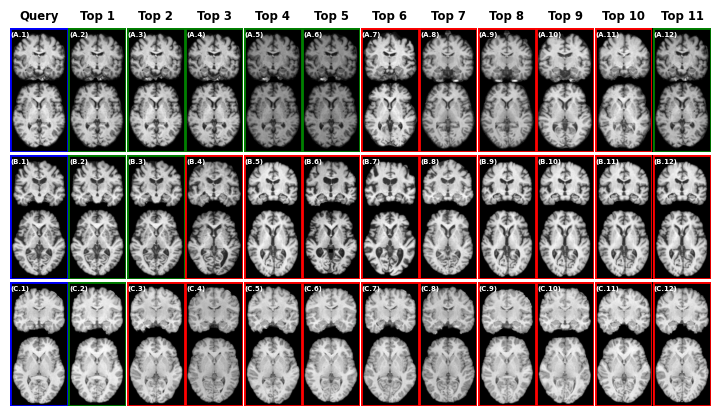

In [97]:
import matplotlib.patches as patches

K = 11

caps = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

queries_guid = retrieval_df[["query"]].values.flatten().tolist()
title_capss = [[f"({caps[i]}.{j})" for j in range(1, K+2)] for i in range(len(queries_guid))]
column_names = [f"top{i+1}" for i in range(K)]
title_tops = ["Query"] + [f"Top {i+1}" for i in range(K)]

# figure
cm = 1/2.54 
n_queries = len(queries_guid)
fig, axess = plt.subplots(n_queries, K+1, figsize=(18.35*cm, 10.5*cm))#, figsize=(18*cm, n_queries*4.1*cm))

for i_q, (axes, query_guid, title_caps) in enumerate(zip(axess, queries_guid, title_capss)):
# axes = axess[0]

    # Example usage:
    row = retrieval_df.loc[retrieval_df["query"] == query_guid].iloc[0]
    query_subject = row["subject"]  # store once outside loop

    # Load query + top1–5
    paths = [row["brain"]]
    titles = [title_caps[0]]
    labels = []  # will store hit/fail info

    title_caps = title_caps[1:]
    for i, col in enumerate(column_names):
        guid = row[col]
        match_row = metadata.loc[metadata["GUID"] == guid].iloc[0]
        paths.append(match_row["brain"])
        is_hit = match_row["subject"] == query_subject
        labels.append(is_hit)
        # titles.append(f"{title_caps[i]} {'✔' if is_hit else '✘'}")
        titles.append(f"{title_caps[i]}")

    # Load brain volumes
    if len(all_brains) < n_queries:
        brains = [load_nifti(p, DATA_PATH) for p in paths]
        all_brains.append(brains)
    else:
        brains = all_brains[i_q]

    # Plot mid-slices
    plot_brain_slices(brains, 
                      titles, 
                      axes=axes,
                      section='custom',
                      vertical_flip=False)
    
    # --- Add borders ---
    for j, ax in enumerate(axes):
        # query
        if j == 0:
            color = "blue"
        else:
            color = "green" if labels[j-1] else "red"
            
        if i_q == 0:
            ax.set_title(title_tops[j], fontweight="bold")

        rect = patches.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,
            linewidth=2.0,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)
        

    # Caption
    n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
    print(f"{titles[0]}: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
    print("Other scans:")
    for t_cap, col in zip(title_caps, column_names):
        guid = row[col]
        project = metadata.loc[metadata["GUID"] == guid]["project"].iloc[0]
        print(f"{t_cap} {guid} - {project}")
        
        


# axess[0][0].set_title("Query", fontweight="bold")
# axess[0][1].set_title("Top 1", fontweight="bold")
# axess[0][2].set_title("Top 2", fontweight="bold")
# axess[0][3].set_title("Top 3", fontweight="bold")
# axess[0][4].set_title("Top 4", fontweight="bold")
# axess[0][5].set_title("Top 5", fontweight="bold")

plt.tight_layout()
plt.subplots_adjust(wspace=0.0, hspace=0.02)

plt.savefig(f"dev/figures/example_brain_retrieval.pdf", format='pdf', 
dpi=600,  # increase for higher-resolution embedded images
bbox_inches='tight', pad_inches=0)
plt.show()


In [35]:
title_caps

['(A.2)',
 '(A.3)',
 '(A.4)',
 '(A.5)',
 '(A.6)',
 '(A.7)',
 '(A.8)',
 '(A.9)',
 '(A.10)',
 '(A.11)',
 '(A.12)']

In [8]:
halt

NameError: name 'halt' is not defined

**FIGURE: EXAMPLE OF RESULT - GT FOR BRAIN REGION**

In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

### Input data
# Path to dataset
DATA_PATH = "/mnt/kth_cbh/fenda/Datasets/" #"/mnt/kth_cbh/fenda/Datasets" # "/home/maia-user/cifs/Datasets/"


In [9]:
def load_dataset_region_brain():
    # Constants
    embedding_file = "dev/data_private/results/region_brain/eval__d_32__m_02__lid_02__mid_02__pn_005/projected_embeddings.parquet"
    metadata_path = "/mnt/alvis2/mimer_user/felixnie/batched_datasets/combined_metadata.csv"
    
    # Load and filter metadata
    clinical_ds = pd.read_csv(metadata_path)
    
    # Filter out bad quality
    clinical_ds = clinical_ds[clinical_ds['useable'] == 1]

    # Load real features from parquet
    emb_path = os.path.join(embedding_file)  # e.g., "outputs/embeddings.parquet"
    df_embs = pd.read_parquet(emb_path)

    # Ensure GUID is string and joinable
    df_embs["GUID"] = df_embs["GUID"].astype(str)
    df_embs["LabelName"] = df_embs["LabelName"].astype(str)
    clinical_ds["GUID"] = clinical_ds["GUID"].astype(str)

    # Merge on GUID
    metadata = pd.merge(clinical_ds, df_embs, on="GUID", how="inner")
    
    # Apply filters to metadata
    metadata = metadata.query("repet == 1").reset_index(drop=True)
    metadata = metadata.query("useable == 1").reset_index(drop=True)
    metadata = metadata.query("mislabel == 0").reset_index(drop=True)
    metadata['subject'] = metadata['subject'].replace('', pd.NA)
    metadata = metadata.dropna(subset=['subject']).reset_index(drop=True)
    metadata = metadata.dropna(subset=['partition']).reset_index(drop=True)

    # Convert embedding columns into a single 'features' column of vectors
    embedding_cols = [col for col in df_embs.columns if not col in  ["GUID", "LabelName"]]
    metadata["features"] = metadata[embedding_cols].apply(lambda row: row.to_numpy(), axis=1)
    
    # Load labels and bounding boxes for cortical/subcortical structures
    labels_df = pd.read_csv("data/labels.csv")
    bb_df = pd.read_csv("data/bounding_boxes.csv")
    labels_bb_df = pd.merge(labels_df, bb_df, on="LabelName", how="inner") # Merge on the 'GUID' column
    return metadata, labels_bb_df

metadata, labels_bb_df = load_dataset_region_brain()
dataset = metadata

In [29]:
dataset.head()

,GUID,project,subject,timepoint,repet,scan_type,field_strength,manufacturer,model_name,disease,...,23,24,25,26,27,28,29,30,31,features
0,11c21c8b-e574-466a-9459-656e09277e24,adni,002_S_0295,m00,1,T1,1.5,NaN,NaN,CN,...,-0.077169,0.233424,0.381726,-0.197074,0.063442,-0.036760,-0.377183,-0.059882,-0.089664,"[0.17348035, 0.0795604, -0.42394644, 0.2202498..."
1,11c21c8b-e574-466a-9459-656e09277e24,adni,002_S_0295,m00,1,T1,1.5,NaN,NaN,CN,...,-0.313615,0.081405,0.065025,0.396240,0.062861,0.079041,0.282852,-0.103432,0.348733,"[-0.005352974, -0.5896711, 0.28412244, 0.00411..."
2,11c21c8b-e574-466a-9459-656e09277e24,adni,002_S_0295,m00,1,T1,1.5,NaN,NaN,CN,...,-0.077596,-0.117974,-0.279802,-0.230992,0.586374,-0.326183,0.240949,0.431378,0.099215,"[0.28115094, 0.27226713, -0.4353115, 0.0747822..."
3,11c21c8b-e574-466a-9459-656e09277e24,adni,002_S_0295,m00,1,T1,1.5,NaN,NaN,CN,...,-0.157901,0.244575,0.190493,0.019042,0.363930,-0.041942,0.007600,0.069612,0.436489,"[-0.28822833, -0.04071009, 0.17795926, 0.23025..."
4,11c21c8b-e574-466a-9459-656e09277e24,adni,002_S_0295,m00,1,T1,1.5,NaN,NaN,CN,...,0.012598,0.101755,0.051769,-0.464571,-0.276021,-0.236738,-0.013602,0.459986,-0.258768,"[0.023792297, -0.093050405, 0.1277362, -0.1955..."


In [10]:

from dev.cbir.evaluation import retrieve_topk_for_queries

struct_name = "Right-Hippocampus"
# manual_query_guids = ["OAS30001_MR_d0129", "OAS30003_MR_d0558", "OAS31470_MR_d0007"]
manual_query_guids = ['I473565', '11c21c8b-e574-466a-9459-656e09277e24', 'I445791']
# queries = dataset.sample(n=3, random_state=145)
subset = dataset.query(f"LabelName == '{struct_name}'")
queries = subset[subset["GUID"].isin(manual_query_guids)]
queries = queries.reset_index(drop=True)
retrieval_df = retrieve_topk_for_queries(subset, queries, top_k=-1, exclude_same_subject=False)
retrieval_df = pd.merge(retrieval_df, subset, left_on="query", right_on="GUID", how="left")
retrieval_df[["query"]].values.flatten().tolist()

Retrieving: 100%|██████████| 3/3 [00:00<00:00, 208.75it/s]


['11c21c8b-e574-466a-9459-656e09277e24', 'I473565', 'I445791']

In [11]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rcParams.update({'font.size': 7})

def crop_mri(image, target_shape=(160, 176, 208)):
    start = [48, 38, 10]
    end = np.minimum(np.array(start) + np.array(target_shape), image.shape)
    cropped = image[start[0]:end[0], start[1]:end[1], start[2]:end[2]]
    return cropped

def load_nifti(path, data_path):
    """Load a nii.gz or mgz file given a relative path from metadata."""
    full_path = os.path.join(data_path, path)
    img = nib.load(full_path)
    return crop_mri(img.get_fdata())

def plot_struct_slices(brains, titles, slice_index=None, axes=None):
    """Plot middle slice (or given slice) of each brain in a row."""
    
    for i, (brain, title) in enumerate(zip(brains, titles)):
        # pick middle slice if not given
        idx = slice_index or brain.shape[0] // 2  
        axes[i].imshow(brain[idx, :, : ].T, cmap="gray", origin="lower")
        # axes[i].set_title(title, y=0.9, x=0.35, va="top", color='w') #, fontsize=8)
        axes[i].axis("off")
        axes[i].text(0.02, 0.96, title, horizontalalignment='left', 
                     verticalalignment='top', transform=axes[i].transAxes, color='w', fontsize=5, fontweight="bold")
        
def obtain_struct(brain_path, seg_path, DATA_PATH, target_struct_name, labels_bb_df):
    image = load_nifti(brain_path, DATA_PATH).astype(np.float32)
    seg = load_nifti(seg_path, DATA_PATH)

    # Filter the label row for the selected structure
    struct_row_df = labels_bb_df.query(f"LabelName == '{target_struct_name}' and Use == 1").reset_index(drop=True)
    if len(struct_row_df) == 0:
        raise ValueError(f"Structure '{target_struct_name}' not found in labels_bb_df with Use == 1.")
    struct_row = struct_row_df.iloc[0]
    struct_map_id = struct_row["LabelID"]

    # Bounding box
    x1, x2 = int(struct_row["min_x"]) - 5, int(struct_row["max_x"]) + 5
    y1, y2 = int(struct_row["min_y"]) - 5, int(struct_row["max_y"]) + 5
    z1, z2 = int(struct_row["min_z"]) - 5, int(struct_row["max_z"]) + 5

    # Preprocess all samples
    patch_brain = image[x1:x2, y1:y2, z1:z2]
    patch_seg = (seg[x1:x2, y1:y2, z1:z2] == struct_map_id)

    struct = patch_brain * patch_seg
    
    return struct


In [29]:
color_map = {}
for i in range(len(labels_bb_df)):
    map_id, R, G, B = labels_bb_df.iloc[i][["MapID", "R", "G", "B"]]
    color_map[int(map_id)] = (int(R), int(G), int(B))

color_map 

{1: (70, 130, 180),
 2: (245, 245, 245),
 3: (205, 62, 78),
 4: (120, 18, 134),
 5: (196, 58, 250),
 6: (0, 148, 0),
 7: (220, 248, 164),
 8: (230, 148, 34),
 9: (0, 118, 14),
 10: (0, 118, 14),
 11: (122, 186, 220),
 12: (236, 13, 176),
 13: (12, 48, 255),
 14: (204, 182, 142),
 15: (42, 204, 164),
 16: (119, 159, 176),
 17: (220, 216, 20),
 18: (103, 255, 255),
 19: (80, 196, 98),
 20: (60, 58, 210),
 21: (60, 58, 210),
 22: (60, 58, 210),
 23: (60, 58, 210),
 24: (60, 60, 60),
 25: (255, 165, 0),
 26: (255, 165, 0),
 27: (0, 255, 127),
 28: (145, 42, 42),
 29: (135, 206, 235),
 30: (160, 32, 240),
 31: (0, 200, 200),
 32: (100, 50, 100),
 33: (122, 135, 50),
 34: (225, 225, 255),
 35: (51, 50, 135),
 36: (74, 155, 60),
 37: (120, 62, 43),
 38: (74, 155, 60),
 39: (122, 135, 50),
 40: (70, 130, 180),
 41: (245, 245, 245),
 42: (205, 62, 78),
 43: (120, 18, 134),
 44: (196, 58, 250),
 45: (0, 148, 0),
 46: (220, 248, 164),
 47: (230, 148, 34),
 48: (0, 118, 14),
 49: (0, 118, 14),
 50

In [18]:
example = metadata.iloc[0]

In [ ]:
brain = load_nifti(example["brain"], DATA_PATH)
seg = load_nifti(example["seg"], DATA_PATH)
seg_rgb = np.zeros(seg.shape + (3,), dtype=np.float32)
for map_id, (R, G, B) in color_map.items():
    # replace map_id in seg with the rgb color (normalized to [0,1])
    seg_rgb[seg == map_id] = (R/255.0, G/255.0, B/255.0)
seg_rgb

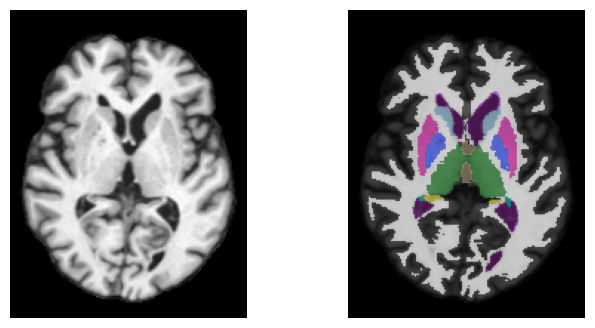

In [68]:
idx = brain.shape[1] // 2 
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(brain[:, idx, :].T, cmap="gray", origin="lower")
axes[0].axis("off")

brain_rgb = np.stack([brain, brain, brain], axis=-1) / np.max(brain)
axes[1].imshow(np.transpose(brain_rgb[:, idx, :], (1, 0, 2)), origin="lower")
axes[1].imshow(np.transpose(seg_rgb[:, idx, :], (1, 0, 2)), origin="lower", alpha=0.5)
axes[1].axis("off")

plt.savefig(f"dev/figures/example_brain_segmentation.pdf", format='pdf', 
dpi=600,  # increase for higher-resolution embedded images
bbox_inches='tight', pad_inches=0)
plt.show()

In [51]:
seg_rgb[:, idx, :].shape

(160, 208, 3)

In [ ]:

        


# Example usage:
query_guid = "OAS30003_MR_d0558"  # pick one from your metadata
row = retrieval_df.loc[retrieval_df["query"] == query_guid].iloc[0]
query_subject = row["subject"]  # store once outside loop

# Load query + top1–5
paths = [[row["brain"], row["seg"]]]
titles = ["(A)"]

# Plot top K
caps = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
K = 12
title_caps = [f"{caps[i+1]}" for i in range(K)]
title_tops = [f"top{i+1}" for i in range(K)]

# figure
cm = 1/2.54 
fig, axes = plt.subplots(1, K+1, figsize=(18.35*cm, 5*cm))


for i, col in enumerate(title_tops):
    guid = row[col]
    match_row = subset.loc[subset["GUID"] == guid].iloc[0]
    paths.append([match_row["brain"], match_row["seg"]])
    titles.append(f"{title_caps[i]} {"✔" if match_row["subject"] == query_subject else "✘"}")

# Load brain volumes
structs = [obtain_struct(brain_path, seg_path, DATA_PATH, struct_name, labels_bb_df) for brain_path, seg_path in paths]

# Plot mid-slices
plot_struct_slices(structs, titles, axes=axes)

# Caption
n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
print(f"(A) Query: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
print("Other scans:")
for t_cap, col in zip(title_caps, title_tops):
    guid = row[col]
    project = subset.loc[subset["GUID"] == guid]["project"].iloc[0]
    print(f"{t_cap} {guid} - {project}")

plt.tight_layout()
plt.show()

In [34]:
all_structs = []

(A.1): 11c21c8b-e574-466a-9459-656e09277e24 from subject 002_S_0295 with a total of 889.
Other scans:
(A.2) 283ba3d9-0278-4a64-98a8-5f5d2be8cd24 - adni
(A.3) 9dacc1e4-f52f-4b9e-9189-0db3c16b84a4 - adni
(A.4) ae9cdbab-6e48-4cf2-9062-91560cdfa7e4 - adni
(A.5) 4c6770b6-fe89-4f78-91ee-f0ede611bd90 - adni
(A.6) 4150f53e-3ab1-45ac-9b0a-646a96f45a64 - adni
(B.1): I473565 from subject 4 with a total of 285.
Other scans:
(B.2) I164080 - aibl
(B.3) I153522 - aibl
(B.4) OAS30263_MR_d2483 - oasis3
(B.5) OAS30835_MR_d0709 - oasis3
(B.6) OAS30021_MR_d0071 - oasis3
(C.1): I445791 from subject 78 with a total of 95.
Other scans:
(C.2) OAS31018_MR_d0041 - oasis3
(C.3) 5a46af94-8184-4114-944c-90906a332864 - adni
(C.4) OAS31018_MR_d0469 - oasis3
(C.5) OAS31018_MR_d1606 - oasis3
(C.6) 06bf5f12-4d9c-4348-94ce-09472b72fc90 - adni


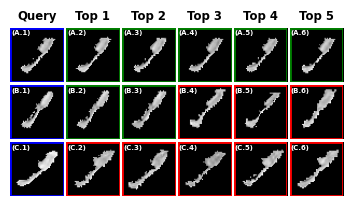

In [37]:
import matplotlib.patches as patches

K = 5

caps = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

queries_guid = retrieval_df[["query"]].values.flatten().tolist()
title_capss = [[f"({caps[i]}.{j})" for j in range(1, K+2)] for i in range(len(queries_guid))]
column_names = [f"top{i+1}" for i in range(K)]
title_tops = ["Query"] + [f"Top {i+1}" for i in range(K)]

# figure
cm = 1/2.54 
n_queries = len(queries_guid)
fig, axess = plt.subplots(n_queries, K+1, 
                          figsize=(9*cm, 5.25*cm), 
                        #   figsize=(18.35*cm, 6.7*cm)
                          )

for i_q, (axes, query_guid, title_caps) in enumerate(zip(axess, queries_guid, title_capss)):
# axes = axess[0]

    # Example usage:
    row = retrieval_df.loc[retrieval_df["query"] == query_guid].iloc[0]
    query_subject = row["subject"]  # store once outside loop

    # Load query + top1–5
    paths = [[row["brain"], row["seg"]]]
    titles = [title_caps[0]]
    labels=[]

    title_caps = title_caps[1:]
    for i, col in enumerate(column_names):
        guid = row[col]
        match_row = subset.loc[subset["GUID"] == guid].iloc[0]
        paths.append([match_row["brain"], match_row["seg"]])
        is_hit = match_row["subject"] == query_subject
        labels.append(is_hit)
        # titles.append(f"{title_caps[i]} {'✔' if is_hit else '✘'}")
        titles.append(f"{title_caps[i]}")

    # Load brain volumes
    if len(all_structs) < n_queries:
        structs = [obtain_struct(brain_path, seg_path, DATA_PATH, struct_name, labels_bb_df) for brain_path, seg_path in paths]
        all_structs.append(structs)
    else:
        structs = all_structs[i_q]
    # structs = [obtain_struct(brain_path, seg_path, DATA_PATH, struct_name, labels_bb_df) for brain_path, seg_path in paths]

    # Plot mid-slices
    plot_struct_slices(structs, titles, axes=axes)
    
    # --- Add borders ---
    for j, ax in enumerate(axes):
        # query
        if j == 0:
            color = "blue"
        else:
            color = "green" if labels[j-1] else "red"
        if i_q == 0:
            ax.set_title(title_tops[j], fontweight="bold")

        rect = patches.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,
            linewidth=2.0,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)

    # Caption
    n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
    print(f"{titles[0]}: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
    print("Other scans:")
    for t_cap, col in zip(title_caps, column_names):
        guid = row[col]
        project = subset.loc[subset["GUID"] == guid]["project"].iloc[0]
        print(f"{t_cap} {guid} - {project}")

plt.tight_layout()
plt.subplots_adjust(wspace=0.04, hspace=0)

plt.savefig(f"dev/figures/example_struct_retrieval.pdf", format='pdf', 
    dpi=600,  # increase for higher-resolution embedded images
    bbox_inches='tight', pad_inches=0)
plt.show()

# plt.savefig(f"figures/example_struct_retrieval.pdf", format='pdf', bbox_inches='tight')
# plt.show()